In [ ]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from cuml.manifold import TSNE, UMAP
import pickle

import time
from tqdm import tqdm

import ipywidgets as widgets
from IPython.display import display

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
# workspace = "/workspace/alvin/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache_cp = pickle.load(f)

gmm_cache = dict()
for key, val in gmm_cache_cp.items():
    new_key = key.replace("/mnt/d/Users/Admin/Projects/dso/SAR_ML", workspace)
    gmm_cache[new_key] = val


In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
seed = 1111
set_seed(seed)

device = torch.device("cuda:0")
torch.cuda.set_device(device)

# ── Model ────────────────────────────────────────────────────────────────────
new_model = models.resnet18(weights=None)
new_model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(new_model.fc.in_features, len(no_aug_synth_ds.class_to_idx))
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed1111_b16.pth"),
    map_location=device
))
new_model = new_model.to(device).eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1]).to(device).eval()

# ── SSR aug synth — 200 epoch accumulation ───────────────────────────────────
SSR_synth_loader = DataLoader(
    synth_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_synth = len(synth_ds)
SSR_synth_feats_gpu  = torch.zeros(200 * n_synth, 512, device=device)
SSR_synth_labels_gpu = torch.zeros(200 * n_synth, dtype=torch.long, device=device)

idx = 0
for epoch in tqdm(range(200), leave=False, position=0, desc="Epochs"):
    with torch.no_grad():
        for inputs, targets in tqdm(SSR_synth_loader, leave=False, position=1, desc="Batches"):
            inputs = inputs.to(device)
            feats = feature_extractor(inputs).view(inputs.size(0), -1)
            bs = feats.size(0)
            SSR_synth_feats_gpu[idx:idx+bs]  = feats
            SSR_synth_labels_gpu[idx:idx+bs] = targets.to(device)
            idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

SSR_synth_feats  = SSR_synth_feats_gpu.cpu().numpy()
SSR_synth_labels = SSR_synth_labels_gpu.cpu().numpy()

# ── no aug synth — single pass ───────────────────────────────────────────────────────
synth_loader = DataLoader(
    no_aug_synth_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_no_aug_synth = len(no_aug_synth_ds)
synth_feats_gpu  = torch.zeros(n_no_aug_synth, 512, device=device)
synth_labels_gpu = torch.zeros(n_no_aug_synth, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(synth_loader, leave=False, position=1, desc="Batches"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        synth_feats_gpu[idx:idx+bs]  = feats
        synth_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

synth_feats  = synth_feats_gpu.cpu().numpy()
synth_labels = synth_labels_gpu.cpu().numpy()

# ── meas — single pass ───────────────────────────────────────────────────────
meas_loader = DataLoader(
    meas_ds, batch_size=32,
    shuffle=False, num_workers=8,
    pin_memory=True, persistent_workers=True, prefetch_factor=4,
    worker_init_fn=worker_init_fn,
    generator=torch.Generator().manual_seed(seed)
)

n_meas = len(meas_ds)
meas_feats_gpu  = torch.zeros(n_meas, 512, device=device)
meas_labels_gpu = torch.zeros(n_meas, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, targets in tqdm(meas_loader, leave=False, desc="Meas"):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs).view(inputs.size(0), -1)
        bs = feats.size(0)
        meas_feats_gpu[idx:idx+bs]  = feats
        meas_labels_gpu[idx:idx+bs] = targets.to(device)
        idx += bs

torch.cuda.synchronize()  # Ensure all GPU operations are complete before moving data to CPU

meas_feats  = meas_feats_gpu.cpu().numpy()
meas_labels = meas_labels_gpu.cpu().numpy()

[2026-05-27 14:11:23.470] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-05-27 14:11:23.471] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-05-27 14:11:23.471] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


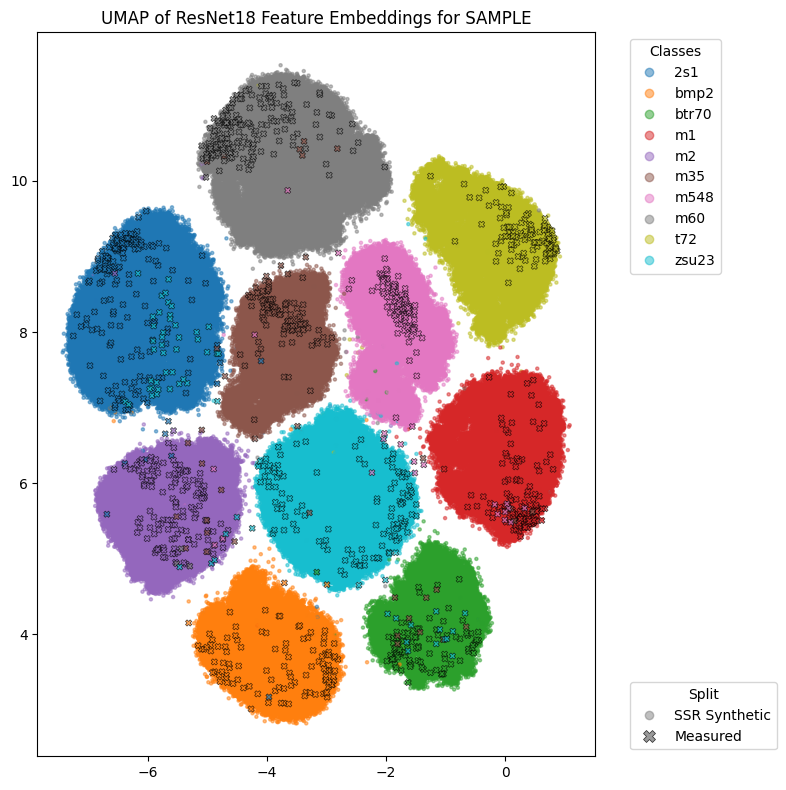

In [9]:
combined_feats = np.concatenate([SSR_synth_feats,  meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, meas_labels], axis=0)

reducer = UMAP(
    n_neighbors=250,
    min_dist=0.25,
    n_components=2,
    metric = "cosine",
)

features_2d = reducer.fit_transform(combined_feats)

# Get class names from the dataset
class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(SSR_synth_feats), 0],
    features_2d[:len(SSR_synth_feats), 1],
    c=combined_labels[:len(SSR_synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats):, 0],
    features_2d[len(SSR_synth_feats):, 1],
    c=combined_labels[len(SSR_synth_feats):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

In [13]:
# define these once outside the function
split_labels = ['SSR Synthetic'] * len(SSR_synth_feats) + ['Measured'] * (len(combined_labels) - len(SSR_synth_feats))
cmap = plt.cm.tab10
norm = plt.Normalize(vmin=0, vmax=len(class_names) - 1)

def plot_zoomed(selected_classes, percentile=95, padding=1):
    ...
cmap = plt.cm.tab10
norm = plt.Normalize(vmin=0, vmax=len(class_names) - 1)

def plot_zoomed(selected_classes, percentile=95, padding=1):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    all_x, all_y = [], []
    
    for class_idx, class_name in enumerate(class_names):
        color = cmap(norm(class_idx))
        is_selected = class_name in selected_classes
        
        for split, marker, size, alpha in [('SSR Synthetic', 'o', 5, 0.5), ('Measured', 'X', 20, 0.8)]:
            split_mask = np.array(split_labels) == split
            class_mask = combined_labels == class_idx
            m = split_mask & class_mask
            
            ax.scatter(
                features_2d[m, 0], features_2d[m, 1],
                s=size, alpha=alpha,  # fade unselected
                marker=marker,
                color=color,
                label=f'{class_name} ({split})' if is_selected else '_nolegend_',
                edgecolors='k' if split == 'Measured' else 'none',
                linewidths=0.5,
                zorder=2 if is_selected else 1  # selected on top
            )
        
        # only use selected classes for zoom bounds
        if is_selected:
            class_mask_all = combined_labels == class_idx
            all_x.extend(features_2d[class_mask_all, 0])
            all_y.extend(features_2d[class_mask_all, 1])
    
    all_x, all_y = np.array(all_x), np.array(all_y)
    lo = (100 - percentile) / 2
    hi = 100 - lo
    ax.set_xlim(np.percentile(all_x, lo) - padding, np.percentile(all_x, hi) + padding)
    ax.set_ylim(np.percentile(all_y, lo) - padding, np.percentile(all_y, hi) + padding)
    
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_title(f'Zoomed UMAP: {", ".join(selected_classes)} ({percentile}th percentile)')
    plt.tight_layout()
    plt.show()

selector = widgets.SelectMultiple(
    options=class_names,
    value=[class_names[0]],
    description='Classes:',
    layout=widgets.Layout(height='200px')
)
percentile_slider = widgets.IntSlider(
    value=95, min=50, max=100, step=5,
    description='Percentile:'
)

widgets.interactive(plot_zoomed, selected_classes=selector, percentile=percentile_slider)

interactive(children=(SelectMultiple(description='Classes:', index=(0,), layout=Layout(height='200px'), option…

[2026-05-27 14:23:43.842] [CUML] [info] Building knn graph using nn descent (configured from build_algo='auto')
[2026-05-27 14:23:43.843] [CUML] [warning] to use nn descent as the build algo, nnd_graph_degree should be larger than or equal to n_neigbors. setting nnd_graph_degree to n_neighbors.
[2026-05-27 14:23:43.843] [CUML] [warning] to use nn descent as the build algo, nnd_intermediate_graph_degree should be larger than or equal to nnd_graph_degree. setting nnd_intermediate_graph_degree to nnd_graph_degree


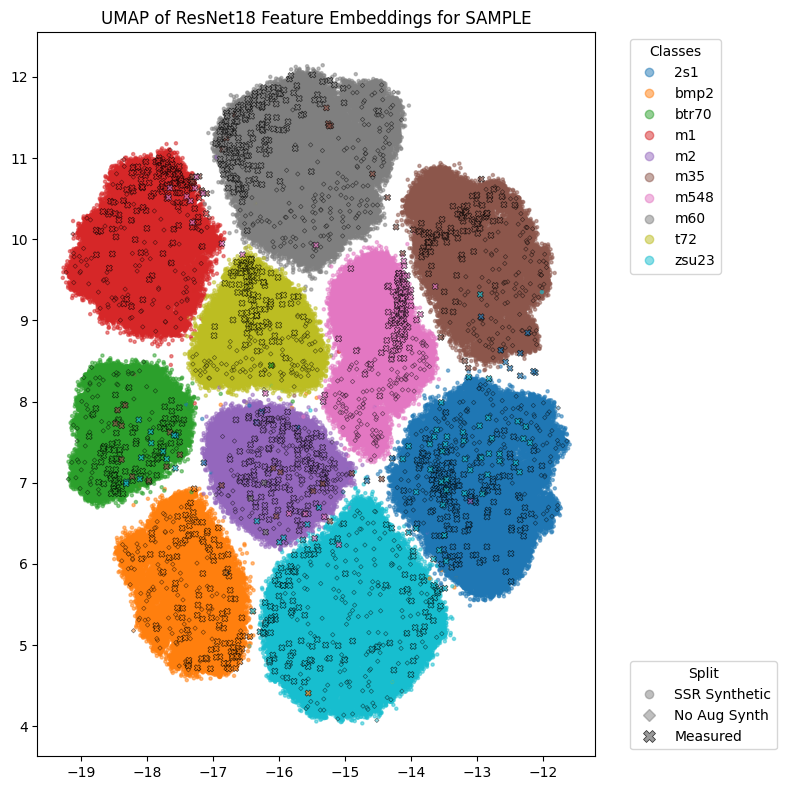

In [18]:
combined_feats = np.concatenate([SSR_synth_feats,  synth_feats, meas_feats],  axis=0)
combined_labels = np.concatenate([SSR_synth_labels, synth_labels, meas_labels], axis=0)

reducer = UMAP(
    n_neighbors=250,
    min_dist=0.25,
    n_components=2,
    metric = "cosine",
)

features_2d = reducer.fit_transform(combined_feats)

# Get class names from the dataset
class_names = [name for name, idx in sorted(no_aug_synth_ds.class_to_idx.items(), key=lambda x: x[1])]

n_classes = len(class_names)

fig = plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:len(SSR_synth_feats), 0],
    features_2d[:len(SSR_synth_feats), 1],
    c=combined_labels[:len(SSR_synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    marker = "o",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats), 0],
    features_2d[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats), 1],
    c=combined_labels[len(SSR_synth_feats):len(SSR_synth_feats)+len(synth_feats)],
    cmap="tab10",
    s=5,
    alpha=0.5,
    linewidths=0.5,
    marker = "D",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

plt.scatter(
    features_2d[len(SSR_synth_feats)+len(synth_feats):, 0],
    features_2d[len(SSR_synth_feats)+len(synth_feats):, 1],
    c=combined_labels[len(SSR_synth_feats)+len(synth_feats):],
    cmap="tab10",
    s=20,
    alpha=0.7,
    linewidths=0.5,
    marker = "X",
    edgecolors="k",
    vmin=0, vmax=n_classes - 1
)

class_legend = plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

fig.add_artist(class_legend)  # keep it when adding the second legend

# Marker legend for train vs test
marker_handles = [
    Line2D([0], [0], marker="o", color="grey", linestyle="None", markersize=6, alpha=0.5, label="SSR Synthetic"),
    Line2D([0], [0], marker="D", color="grey", linestyle="None", markersize=6, alpha=0.5, label="No Aug Synth"),
    Line2D([0], [0], marker="X", color="grey", linestyle="None", markersize=8, alpha=0.8, markeredgecolor="k", markeredgewidth=0.5, label="Measured"),
]
plt.legend(handles=marker_handles, title="Split", bbox_to_anchor=(1.05, 0), loc="lower left")

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()